(p2-theory-classification)=
# P2 이론: 분류

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**학습 목표**

이번 P2에서는 **분류 모델을 어떻게 평가하고, 예측 결과를 어떻게 해석할 것인가**에 집중한다.

학습을 마치면 다음을 설명할 수 있어야 한다.

- 회귀와 분류의 차이를 설명할 수 있다.
- 이진 분류에서 양성·음성, TP·TN·FP·FN의 의미를 구분할 수 있다.
- 로지스틱 회귀가 확률을 이용해 클래스를 결정하는 원리를 설명할 수 있다.
- 정확도만으로 분류 모델을 평가하기 어려운 경우를 설명할 수 있다.
- 정밀도와 재현율을 계산하고, 두 지표의 트레이드오프를 해석할 수 있다.
- ROC 곡선과 AUC의 의미를 설명할 수 있다.
- 다중 클래스 분류에서 클래스별 확률과 혼동 행렬을 해석할 수 있다.
- 검증셋과 테스트셋의 역할을 구분할 수 있다.

> 이 노트에서는 **분류 모델의 의미와 평가**에 집중한다. 로지스틱 회귀의 파라미터가 실제로 어떻게 최적화되는지는 P3의 경사하강법에서 다룬다.

## 분류 문제와 MNIST

### 회귀와 분류

머신러닝의 지도학습 문제는 크게 **회귀**(regression)와 **분류**(classification)로 나눌 수 있다.

회귀는 주택 가격, 수요량처럼 **연속적인 숫자값**을 예측한다. 반면 분류는 이메일이 스팸인지 아닌지, 사진 속 숫자가 무엇인지처럼 **미리 정해진 범주**를 예측한다.

MNIST 문제에서 입력은 손글씨 이미지이고, 타깃은 `0`부터 `9`까지의 숫자다. 따라서 이 문제는 10개의 클래스 중 하나를 선택하는 분류 문제다.

### MNIST 데이터셋

MNIST는 0부터 9까지의 손글씨 숫자 이미지 70,000개로 구성된다. 각 이미지는 원래 `28 × 28` 픽셀이지만, 일반적인 사이킷런 모델에서는 한 이미지를 784개의 특성으로 펼쳐 사용한다.

즉 한 이미지는 다음과 같이 생각할 수 있다.

$$
28 \times 28 = 784
$$

따라서 전체 입력 데이터는 `70,000 × 784` 형태가 된다. **한 행은 하나의 이미지, 한 열은 하나의 픽셀 특성**을 의미한다.

### 하나의 이미지는 어떻게 보이는가?

P2 실습에서 첫 번째 샘플을 다시 `28 × 28` 형태로 바꾸어 확인하면 아래와 같은 숫자 5 이미지가 나타난다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-ml/blob/master/images/ch03/mnist_digit_5.png?raw=true" width="300"/>
</div>

머신러닝 모델은 이 그림 자체를 보는 것이 아니라, 784개 픽셀의 숫자값을 입력으로 받아 픽셀의 분포에서 특정 패턴을 학습한다.

### 훈련셋, 검증셋, 테스트셋

모델의 성능을 올바르게 평가하려면 데이터의 역할을 구분해야 한다.

- **훈련셋(training set)**: 모델의 파라미터를 학습하는 데 사용한다.
- **검증셋(validation set)**: 모델이나 결정 임곗값을 선택하고 조정하는 데 사용한다.
- **테스트셋(test set)**: 모든 선택이 끝난 뒤 최종 일반화 성능을 확인하는 데 사용한다.

테스트셋은 훈련 과정에서 절대로 사용하지 않는다. 

MNIST 데이터의 경우 60,000개를 개발 과정에 사용하고, 마지막 10,000개를 최종 테스트용으로 남겨 둔다. 다시 60,000개 중 일부를 검증셋으로 분리한다.

### 층화 샘플링이 필요한 이유

이진 분류에서는 양성과 음성의 비율이 중요하다. 예를 들어 숫자 5는 전체 훈련 데이터의 약 9% 정도다.

훈련셋과 검증셋을 단순히 무작위로 나누면 우연히 숫자 5의 비율이 달라질 수 있다. 

이처럼 클래스 비율이 불균형일 때에는 층화 샘플링을 적용하여 클래스 비율이 각 데이터셋에서도 비슷하게 유지되도록 한다.

## 이진 분류와 로지스틱 회귀

### 숫자 5인가, 아닌가?

10개의 숫자를 한꺼번에 분류하기 전에 문제를 단순화해 보자.

- 숫자 5 → **양성(positive)**
- 숫자 5가 아님 → **음성(negative)**

이제 모델은 입력 이미지를 보고 `True` 또는 `False` 중 하나를 선택한다. 이렇게 두 클래스 중 하나를 선택하는 문제를 **이진 분류(binary classification)**라고 한다.

여기서 양성과 음성이라는 표현은 좋고 나쁨을 의미하지 않는다. 단지 **관심 있는 클래스를 양성으로 정한 것**이다.

### 로지스틱 회귀는 왜 분류 모델인가?

이름에는 ‘회귀’가 들어 있지만 로지스틱 회귀는 대표적인 **분류 모델**이다.

먼저 입력 특성의 선형 결합으로 하나의 점수 $z$를 계산한다.

$$
z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$

그다음 이 점수를 **시그모이드(sigmoid) 함수**에 통과시켜 0과 1 사이의 값으로 바꾼다.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

이 값을 양성 클래스에 속할 확률로 해석한다.

$$
\hat p = P(y=1 \mid \mathbf{x})
$$

즉 로지스틱 회귀의 핵심은 다음 흐름으로 이해할 수 있다.

> **입력 특성 → 선형 점수 → 확률 → 클래스 결정**

### 확률에서 클래스로

모델이 숫자 5일 확률을 `0.82`라고 예측했다고 하자. 기본 결정 임곗값이 `0.5`라면 이 이미지는 숫자 5로 분류된다.

$$
\hat y =
\begin{cases}
1 & \text{if } \hat p \ge t \\
0 & \text{if } \hat p < t
\end{cases}
$$

여기서 $t$가 **결정 임곗값(decision threshold)**이다. 로지스틱 회귀에서는 보통 $t=0.5$를 기본값으로 사용하지만, 문제의 목적에 따라 다른 값을 선택할 수 있다.

중요한 점은 **모델이 먼저 확률을 계산하고, 임곗값이 그 확률을 최종 클래스 판단으로 바꾼다**는 것이다.

## 혼동 행렬

### 맞았는가보다 어떻게 틀렸는가가 중요하다

이진 분류의 결과는 네 가지 경우로 나눌 수 있다.

| | 예측 음성 | 예측 양성 |
|---|---:|---:|
| **실제 음성** | TN | FP |
| **실제 양성** | FN | TP |

- **TP(True Positive)**: 실제 양성을 양성으로 맞게 예측
- **TN(True Negative)**: 실제 음성을 음성으로 맞게 예측
- **FP(False Positive)**: 실제 음성을 양성으로 잘못 예측
- **FN(False Negative)**: 실제 양성을 음성으로 잘못 예측

P2 실습의 검증셋에서는 다음 결과가 나왔다.

| | 예측 음성 | 예측 양성 |
|---|---:|---:|
| **실제 음성** | 9,032 | 65 |
| **실제 양성** | 205 | 698 |

즉 숫자 5가 아닌 이미지를 5라고 잘못 판단한 경우가 65개이고, 실제 숫자 5를 놓친 경우가 205개다.

### 혼동 행렬 이해

아래 그림은 이진 분류기의 혼동 행렬에 포함된 네 정수의 의미를 설명하기 위해
숫자-5 판별기의 판별 결과를 단순화하였다.

<div align="center">
       <img src="https://github.com/codingalzi/code-workout-ml/blob/master/images/ch03/homl03-02.png?raw=true" width="500"/>
</div>

위 단순화된 그림을 토대로한 혼동 행렬은 다음과 같다.

```python
array([[5, 1],
       [2, 3]])
```

아래 표는 위 그림에 포함된 각 칸을 가리키는 용어와 칸에 포함된 손글씨 이미지들에 대해 설명한다.

| 실제 라벨 | 예측: 음성 (5 아니라고 판별) | 예측: 양성 (5라고 판별) |
| :--- | :--- | :--- |
| 음성<br>(5 아님) | TN (참 음성, True Negative)<br>5 아닌 숫자를 5가 아니라고 예측<br>(예: 8, 3, 9, 7, 2) | FP (거짓 양성, False Positive)<br>5 아닌 숫자를 5라고 예측<br>(예: 6) |
| 양성<br>(5 맞음) | FN (거짓 음성, False Negative)<br>실제 5인 숫자를 5가 아니라고 예측 | TP (참 양성, True Positive)<br>실제 5인 숫자를 5라고 예측 |


## 정확도, 정밀도, 재현율

### 정확도

정확도(accuracy)는 전체 예측 중 맞게 예측한 비율이다.

$$
\mathrm{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
$$

직관적이고 이해하기 쉽지만, 클래스의 비율이 크게 다른 경우에는 주의해야 한다.

P2 실습에서 숫자 5는 약 9%뿐이다. 따라서 모든 이미지를 무조건 “5가 아니다”라고 예측해도 정확도가 약 `0.910`이 된다. 실제 로지스틱 회귀의 정확도는 `0.973`이지만, **높은 정확도라는 숫자만 보고 모델이 충분히 좋은지 판단해서는 안 된다.**

모든 이미지를 “5가 아니다”라고 예측하더라도 91%의 높은 정확도가 나온다. 

클래스 비율이 불균형한 문제에서는 정확도만으로 모델을 평가하기 어렵다.

### 정밀도

정밀도(precision)는 **양성이라고 예측한 것 중 실제로 양성인 비율**이다.

$$
\mathrm{Precision} = \frac{TP}{TP+FP}
$$

정밀도가 중요하다는 것은 **거짓 양성(FP)을 줄이고 싶다**는 뜻과 연결된다.

예를 들어 어떤 경보 시스템이 양성이라고 판단할 때마다 큰 비용이 발생한다면, 잘못된 양성 판정을 줄여 정밀도를 높일 필요가 있다.

P2 실습에서 기본 임곗값을 사용했을 때 정밀도는 약 `0.915`였다. 즉 숫자 5라고 예측한 이미지 가운데 약 91.5%가 실제 숫자 5였다.

### 재현율

재현율(recall)은 **실제 양성 중 모델이 찾아낸 비율**이다.

$$
\mathrm{Recall} = \frac{TP}{TP+FN}
$$

재현율이 중요하다는 것은 **거짓 음성(FN), 즉 실제 양성을 놓치는 경우를 줄이고 싶다**는 뜻과 연결된다.

대표적으로 암진단의 경우 양성 암을 놓치지 않으려면 재현율을 최대한 올려야 한다.

P2 실습에서 기본 임곗값의 재현율은 약 `0.773`이었다. 실제 숫자 5의 약 77.3%를 찾아낸 셈이다.

### 어떤 지표가 더 중요한가?

정밀도와 재현율 중 하나가 항상 더 좋은 지표인 것은 아니다. **문제의 목적이 무엇인지**에 따라 중요도가 달라진다.

- FP가 특히 큰 문제라면 정밀도를 중요하게 볼 수 있다.
- FN이 특히 큰 문제라면 재현율을 중요하게 볼 수 있다.
- 두 종류의 오류가 모두 중요하면 두 지표를 함께 확인해야 한다.

즉 성능 지표를 선택하는 일도 모델링의 일부다.

## 결정 임곗값과 정밀도·재현율의 트레이드오프

### 임곗값을 높이면 무엇이 달라지는가?

결정 임곗값을 높이면 모델이 양성이라고 판단하기 어려워진다.

- 양성 예측 수가 감소한다.
- FP가 줄어들 가능성이 커진다.
- 정밀도는 높아지는 경향이 있다.
- 실제 양성도 일부 놓치므로 재현율은 낮아지는 경향이 있다.

반대로 임곗값을 낮추면 더 많은 샘플을 양성으로 판단하므로 재현율은 높아지고 정밀도는 낮아질 수 있다.

이 관계를 **정밀도와 재현율의 트레이드오프**라고 한다.

### 임곗값에 따른 변화

P2 실습에서 임곗값을 변화시키며 정밀도와 재현율을 계산한 결과다.

<div align="center">
       <img src="https://github.com/codingalzi/code-workout-ml/blob/master/images/ch03/threshold_pr.png?raw=true" width="600"/>
</div>

**주의사항**

임곗값을 움직이는 것이 모델 자체를 다시 훈련하는 일이 아니라 최종 의사결정 기준을 바꾸는 일이다.

### Precision–Recall 곡선

정밀도와 재현율을 직접 서로의 축에 놓으면 다음과 같은 곡선을 얻는다.

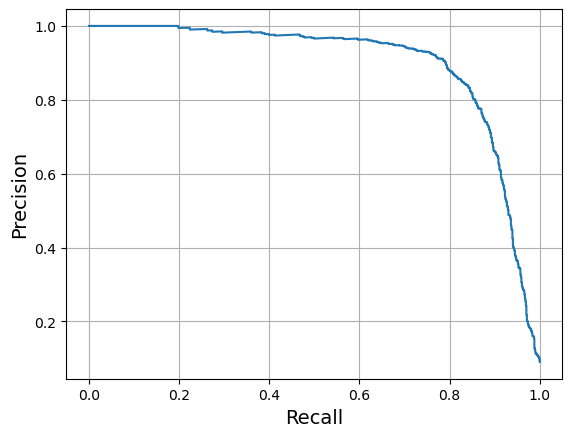

이 곡선은 가능한 여러 임곗값이 만들어 내는 정밀도와 재현율의 조합을 보여준다. 따라서 **어느 지점에서 균형을 잡을 것인지**를 판단하는 데 사용할 수 있다.

P2 실습에서는 정밀도를 약 90% 이상으로 유지하도록 임곗값을 선택했을 때, 검증셋에서 정밀도는 약 `0.900`, 재현율은 약 `0.791`이었다.

## ROC 곡선과 AUC

### TPR과 FPR

ROC 곡선은 임곗값을 변화시키면서 다음 두 비율을 비교한다.

**TPR**(True Positive Rate)은 실제 양성 중 양성으로 맞게 예측한 비율이다. 따라서 재현율과 같다.

$$
\mathrm{TPR} = \frac{TP}{TP+FN}
$$

**FPR**(False Positive Rate)은 실제 음성 중 양성으로 잘못 예측한 비율이다.

$$
\mathrm{FPR} = \frac{FP}{FP+TN}
$$

좋은 분류기는 가능한 한 **TPR은 높고 FPR은 낮은 상태**를 만들어야 한다.

### ROC 곡선을 읽는 방법

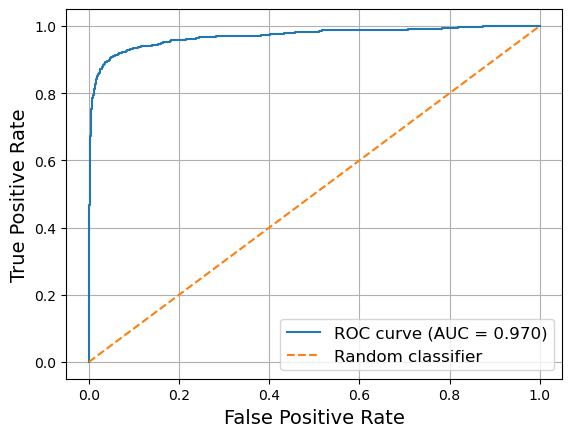

대각선은 무작위 분류에 가까운 기준선이다. ROC 곡선이 왼쪽 위에 가까울수록 적은 거짓 양성으로 많은 실제 양성을 찾아낸다는 뜻이다.

P2 실습의 ROC-AUC는 약 `0.970`이었다.

### AUC란 무엇인가?

AUC(Area Under the Curve)는 ROC 곡선 아래의 면적이다.

- `AUC = 1`에 가까울수록 양성과 음성을 잘 구분한다.
- `AUC = 0.5` 정도라면 무작위 분류와 비슷하다.

AUC의 장점은 **하나의 특정 임곗값을 고정하지 않고 여러 임곗값에서의 구분 능력을 하나의 숫자로 요약**한다는 점이다.

다만 양성 클래스가 매우 드문 문제에서는 ROC-AUC만으로 실제 양성 예측의 품질을 충분히 파악하기 어려울 수 있다. 이때는 정밀도와 재현율, Precision–Recall 곡선을 함께 확인하는 것이 좋다.

## 다중 클래스 분류

### 두 클래스에서 여러 클래스로

지금까지는 숫자 5인지 아닌지만 구분했다. 이제 원래 문제로 돌아가 `0`부터 `9`까지 10개의 숫자 중 하나를 예측한다.

이처럼 세 개 이상의 클래스 중 하나를 선택하는 문제를 **다중 클래스 분류(multiclass classification)**라고 한다.

### 다중 클래스 로지스틱 회귀

다중 클래스 로지스틱 회귀에서는 각 클래스마다 점수를 계산한 뒤, 이를 클래스별 확률로 변환한다. 대표적으로 **소프트맥스(softmax)**를 사용한다.

클래스 $k$의 점수를 $z_k$라고 하면 클래스 확률은 다음과 같이 계산된다.

$$
\hat p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

모든 클래스 확률의 합은 1이다.

$$
\sum_{k=1}^{K} \hat p_k = 1
$$

최종 예측은 가장 높은 확률을 가진 클래스로 정한다.

$$
\hat y = \operatorname*{argmax}_k \hat p_k
$$

따라서 다중 클래스 분류에서도 핵심 흐름은 동일하다.

> **입력 → 클래스별 점수 → 클래스별 확률 → 가장 높은 확률의 클래스 선택**

### 예측 클래스만 보지 말고 확률도 본다

P2 실습에서 한 검증 샘플의 실제 숫자는 `8`이었지만 모델은 `1`로 잘못 예측했다. 이때 주요 예측 확률은 다음과 같았다.

| 클래스 | 예측 확률 |
|---|---:|
| 1 | 0.750 |
| 8 | 0.202 |
| 6 | 0.035 |
| 5 | 0.011 |

최종 예측값 `1`만 보면 단순히 틀렸다는 사실만 알 수 있다. 하지만 확률을 함께 보면 모델이 `1`을 가장 강하게 선택했지만 `8`에도 어느 정도 가능성을 부여했다는 사실을 알 수 있다.

이처럼 **예측 확률은 모델의 판단 구조를 더 자세히 해석하는 데 도움**이 된다.

### 다중 클래스 혼동 행렬

다중 클래스에서도 혼동 행렬은 유용하다. 행을 실제 클래스, 열을 예측 클래스로 놓으면 어떤 숫자가 어떤 숫자로 잘못 분류되는지 확인할 수 있다.

P2 실습에서는 각 행을 실제 클래스의 비율로 정규화했다. 이 경우 대각선 값은 각 숫자를 올바르게 분류한 비율을 의미한다.

예를 들어 검증 결과에서 다음과 같은 차이가 나타났다.

- 실제 `0` → `0` 예측: 약 `0.971`
- 실제 `1` → `1` 예측: 약 `0.970`
- 실제 `5` → `5` 예측: 약 `0.880`
- 실제 `8` → `8` 예측: 약 `0.882`

즉 전체 정확도 하나만 보면 알 수 없는 **클래스별 난이도 차이**를 확인할 수 있다.

### 오분류 패턴을 읽는다

혼동 행렬의 대각선을 제외하면 오류만 남는다. P2 실습의 검증 결과에서는 다음과 같은 오분류가 상대적으로 눈에 띄었다.

- 실제 `4`를 `9`로 예측: 약 `3.8%`
- 실제 `7`을 `9`로 예측: 약 `3.6%`
- 실제 `3`을 `5`로 예측: 약 `3.4%`
- 실제 `5`를 `3`으로 예측: 약 `3.0%`
- 실제 `2`를 `8`로 예측: 약 `2.9%`

이런 패턴은 단순히 “정확도가 92%다”라는 정보보다 훨씬 구체적이다. **모델이 어떤 형태를 서로 비슷하게 보고 있는지**를 추정하고, 이후 데이터나 모델을 개선할 단서를 얻을 수 있다.

## 검증과 최종 테스트

### 검증셋에서 결정하고 테스트셋에서 확인한다

모델 종류, 전처리 방법, 결정 임곗값처럼 중요한 선택은 검증셋을 이용해 결정한다. 테스트셋은 그 선택을 끝낸 뒤 한 번의 최종 확인에 사용한다.

P2 실습에서는 검증셋에서 정밀도 약 90%를 목표로 임곗값을 선택한 뒤, 같은 임곗값을 테스트셋에 그대로 적용했다.

테스트 결과는 다음과 같았다.

- 이진 분류 정밀도: 약 `0.895`
- 이진 분류 재현율: 약 `0.814`
- 다중 클래스 정확도: 약 `0.921`

검증 성능과 테스트 성능이 완전히 같을 필요는 없다. 중요한 것은 **검증 과정에서 내린 선택이 새로운 데이터에서도 비슷한 수준으로 작동하는지** 확인하는 것이다.

## 분류 모델을 볼 때의 판단 순서

분류 문제에서는 단순히 정확도가 높은 모델을 찾는 것으로 끝나지 않는다. 다음과 같은 순서로 생각하면 좋다.

1. **무엇을 양성으로 볼 것인가?** 또는 어떤 클래스들을 구분할 것인가?
2. **어떤 오류가 더 중요한가?** FP와 FN의 비용이 같은가?
3. **어떤 지표를 볼 것인가?** 정확도, 정밀도, 재현율, ROC-AUC 중 무엇이 목적과 맞는가?
4. **결정 임곗값은 적절한가?** 기본값 0.5가 항상 최선은 아니다.
5. **특정 클래스에서 반복되는 오류가 있는가?** 혼동 행렬과 예측 확률을 확인한다.
6. **최종 선택이 테스트셋에서도 유지되는가?** 새로운 데이터에서 일반화되는지 확인한다.

이 과정이 바로 분류 모델을 **사용하는 것**을 넘어 **판단하는 것**으로 가는 핵심이다.

## 핵심 정리

- 분류는 미리 정해진 클래스 중 하나를 예측하는 문제다.
- 로지스틱 회귀는 입력으로부터 양성 확률을 계산하고 결정 임곗값을 이용해 클래스를 정한다.
- 혼동 행렬은 TP, TN, FP, FN을 구분하여 어떤 오류가 발생했는지 보여준다.
- 정확도는 클래스 불균형이 있을 때 오해를 만들 수 있다.
- 정밀도는 양성 예측의 신뢰성, 재현율은 실제 양성을 얼마나 찾아냈는지를 나타낸다.
- 결정 임곗값을 바꾸면 정밀도와 재현율의 균형이 달라진다.
- ROC 곡선은 TPR과 FPR의 관계를, AUC는 여러 임곗값에서의 구분 능력을 요약한다.
- 다중 클래스 로지스틱 회귀는 클래스별 확률을 계산하고 가장 높은 확률의 클래스를 선택한다.
- 다중 클래스 혼동 행렬은 클래스별 성능과 반복되는 오분류 패턴을 찾는 데 유용하다.
- 검증셋은 선택을 위한 데이터이고, 테스트셋은 최종 일반화 성능을 확인하기 위한 데이터다.

## 이해 확인

다음 질문에 자신의 말로 답해 본다.

- 숫자 5가 전체의 9% 정도일 때 정확도만 보는 것이 위험한 이유는 무엇인가?
- FP와 FN은 각각 어떤 오류인가?
- 정밀도와 재현율의 분모는 어떻게 다른가?
- 결정 임곗값을 높이면 일반적으로 정밀도와 재현율은 어떻게 변하는가?
- ROC 곡선에서 좋은 분류기는 어느 방향에 가까운가?
- AUC가 0.5에 가깝다는 것은 무엇을 의미하는가?
- 다중 클래스에서 예측 확률을 보는 것이 최종 예측 클래스만 보는 것보다 어떤 정보를 더 주는가?
- 검증셋으로 임곗값을 선택한 뒤 테스트셋에서 임곗값을 다시 조정하면 왜 문제가 되는가?